# **TikTok Project**
Summerize - Regression Analysis: Simplify complex data relationships**

# **Build a regression model**

### **Imports and loading**
Importing Packages and Data

In [23]:
# Data Manipulation 
import numpy as np
import pandas as pd
# Data Visualization
import matplotlib.pyplot as plt     
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix   
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample
# Data Load
df = pd.read_csv('tiktok_dataset.csv')

### **Explore data with EDA**

Analyzing the data and check for and handle missing values and duplicates.

In [24]:
#First few rows
df.head(10)


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [31]:
# Size of dataset
df.shape

(19382, 12)

In [34]:
# Describtive statistics
df.describe(include='all')

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,19084,1.938200e+04,19382.000000,19084,19382,19382,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
unique,NaN,2,NaN,NaN,19012,2,3,NaN,NaN,NaN,NaN,NaN
top,NaN,claim,NaN,NaN,a colleague learned from the media a claim th...,not verified,active,NaN,NaN,NaN,NaN,NaN
freq,NaN,9608,NaN,NaN,2,18142,15663,NaN,NaN,NaN,NaN,NaN
mean,9691.500000,NaN,5.627454e+09,32.421732,NaN,NaN,NaN,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,NaN,2.536440e+09,16.229967,NaN,NaN,NaN,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,NaN,1.234959e+09,5.000000,NaN,NaN,NaN,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,NaN,3.430417e+09,18.000000,NaN,NaN,NaN,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,NaN,5.618664e+09,32.000000,NaN,NaN,NaN,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,NaN,7.843960e+09,47.000000,NaN,NaN,NaN,504327.000000,125020.000000,18222.000000,1156.250000,292.000000


In [35]:
# General information and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [36]:
# Missing data 
df.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [37]:
# We will drop missing values for simplicity, we could save original dataset if missing values would be important
df.dropna(axis=0, inplace=True)

In [40]:
#Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [76]:
#Function for repetative tasks
#Visualize Distribution with Boxplot
def boxplot(column):
    plt.figure(figsize=(6,2))
    plt.title(column)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    sns.boxplot(data=df, x=column)
    plt.show()



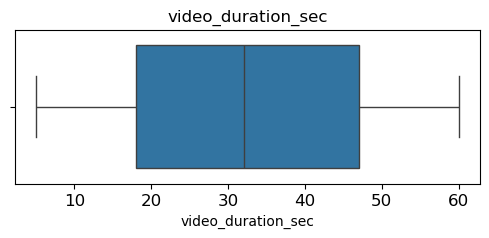

In [ ]:
# Distribution of `video_duration_sec'
boxplot('video_duration_sec')

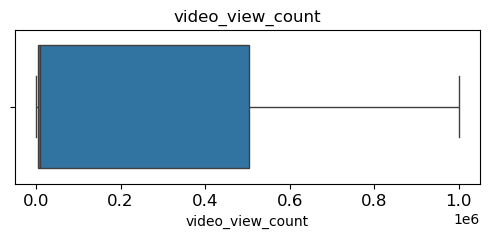

In [78]:
# Distribution of `video_view_count'
boxplot('video_view_count')

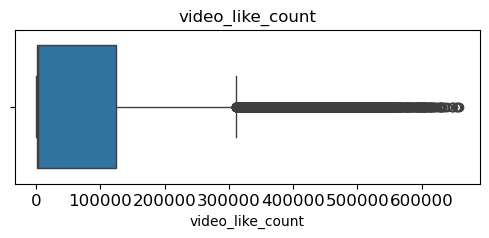

In [79]:
# Distribution of `video_like_count'
boxplot('video_like_count')

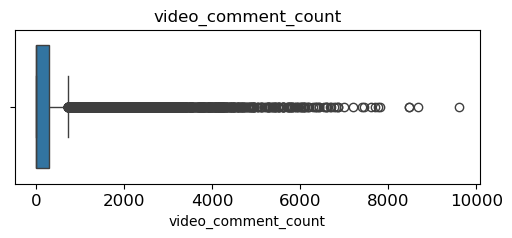

In [80]:
# Distribution of `video_comment_count'
boxplot('video_comment_count')


In [82]:
#Handling Outliers
def outline(column):
    percentile25 = df[column].quantile(0.25)
    percentile75 = df[column].quantile(0.75)

    iqr = percentile75 - percentile25
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 0.5 * iqr
    print(f'Upper Limit: {upper_limit}')
    print(f'Lower Limit: {lower_limit}')

    df.loc[data[column] > upper_limit, column] = upper_limit
    #There is not lower limit than 0, that is the reason we do not add for 'lower_limit'



In [83]:
outline('video_like_count')

Upper Limit: 311333.875
Lower Limit: -61293.875


In [84]:
outline('video_comment_count')

Upper Limit: 728.5
Lower Limit: -144.5


In [88]:
# Checking Verified status dividing percentages
df['verified_status'].value_counts(normalize=True).to_frame().style.format('{:.2%}')

,proportion
verified_status,
not verified,93.71%
verified,6.29%


In [ ]:
#resampling

### **Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [43]:
# Select outcome variable
### YOUR CODE HERE ###


### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [45]:
# Split the data into training and testing sets
### YOUR CODE HERE ###


### **Task 3c. Encode variables**

Check the data types of the features.

In [47]:
# Check data types
### YOUR CODE HERE ###


### **Task 3d. Model building**

Construct a model and fit it to the training set.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

In [74]:
# Create a classification report
### YOUR CODE HERE ###


### **Task 4c. Interpret model coefficients**

In [75]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
### YOUR CODE HERE ###


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?

2. What results can be presented from this project?

==> ENTER YOUR RESPONSE TO QUESTIONS 1 AND 2 HERE

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 